ENVIRONMENT
   python 3.12.13 | numpy 2.0.2 | scipy 1.16.3 | matplotlib 3.10.0

STEP 1 of 8.  SANITY CHECK - worked Example 1 of Vatankhah (2023)        [0.0 min elapsed]
   b = 10.0 m, z = 2.0, Q = 30.0 m3/s, S0 = 0.001, n = 0.013
   beta  = 0.026570
   eps_t = 0.084356     (the paper prints 0.084)
   exact normal depth by root-finding = 1.091302 m
   the paper reports                  = 1.092 m
   [V23] Eq. (10) as implemented here = 1.095017 m
   The framing is confirmed. The small residual between the paper's
   printed answer and the formula evaluated at full precision arises
   from the intermediate rounding shown in the paper's own worked steps.

STEP 2 of 8.  THE TWO PRINTINGS OF THE SEED OF VATANKHAH (2013)        [0.0 min elapsed]
   body text, Eq. (30)      -> sup |error| =    0.2379 %   consistent with the claimed 0.25 %
                               seed left its domain on 0.0 % of the sweep
   summary table            -> sup |error| =   29.3819 %   NOT consistent with th

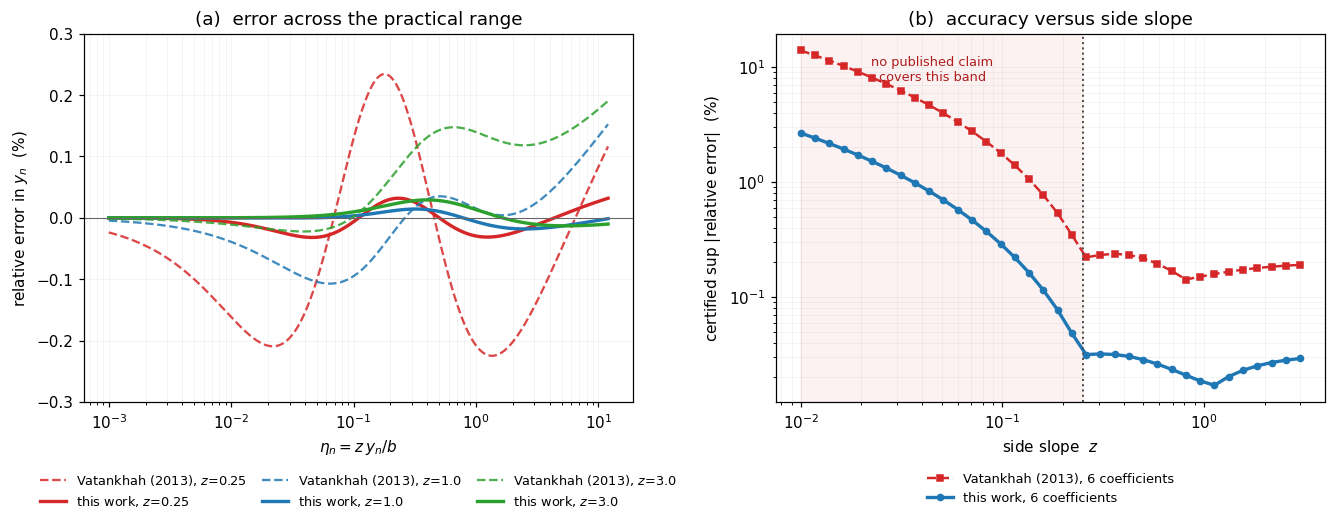

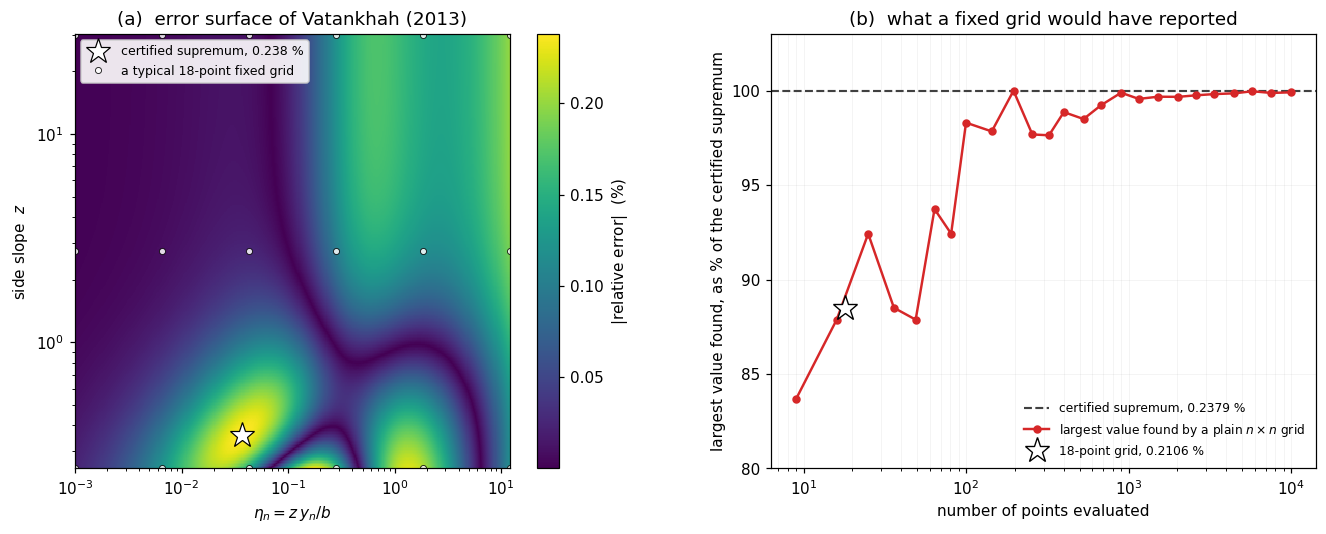

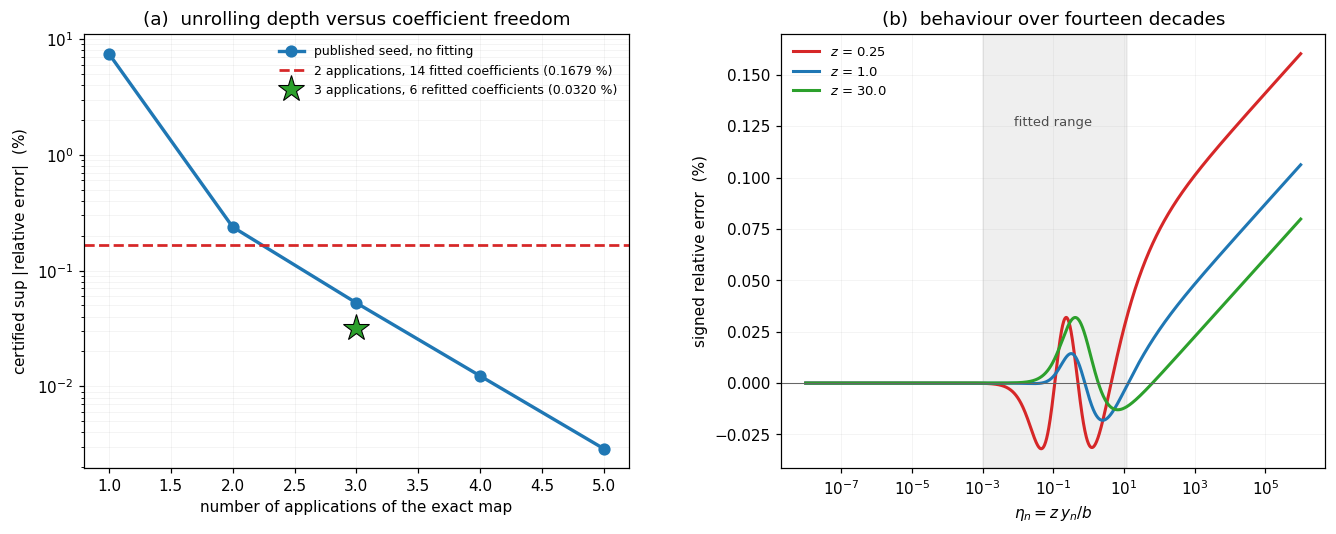


SUMMARY - certified suprema over z >= 0.25
   Vatankhah (2023) Eq. (12), 7 fitted coefficients : 0.7148 %
   Vatankhah (2013),          6 fitted coefficients : 0.2379 %
   this work,                 6 fitted coefficients : 0.0320 %   -> 7.4x more accurate

   PROPOSED SOLUTION
     z*    = z/sqrt(1+z^2) - 1
     eps   = 4*[ z(1+z^2)^(1/3) nQ / (lambda sqrt(S0) b^(8/3)) ]^(3/5)
     t0    = -z* + [ 1.028077*z* + 1.058232*(1 + eps/(z*+1.894670)^0.311905)^0.475387 ]^1.328345
     t     <- sqrt(1 + eps*(z* + t)^0.4)        applied three times
     eta_n = (t - 1)/2 ,   y_n = eta_n*b/z

VALUES QUOTED IN THE MANUSCRIPT
   Table 1, certified suprema : 0.693, 0.238, 0.695, 0.715, 15.984 %
   Section 4.1, table form of the seed of [V13] : 29.3819 %
   Section 3, 18-point fixed grid              : 0.2106 %  against certified 0.2379 %
   Table 2, decomposition     : 0.2379 / 0.1679 / 0.0525 / 0.0320 %
   Section 5.2, spread of the eight fits       : 0.03192 to 0.03308 %, sd 0.00036 %
   Equation

In [1]:
#!/usr/bin/env python3
# =============================================================================
#  NORMAL DEPTH IN TRAPEZOIDAL OPEN CHANNELS:
#  AN AUDIT OF PUBLISHED EXPLICIT SOLUTIONS AND A NEW THREE-LEVEL
#  FIXED-POINT SOLUTION WITH CERTIFIED ERROR BOUNDS
#
#  Complete reproduction script. Every certified supremum, every table entry
#  and every figure reported in the accompanying manuscript is regenerated by a
#  single execution of this file. The only exception is the set of asymptotic
#  limits quoted in the manuscript's discussion of mild side slopes, which are
#  obtained analytically from Eqs. (6), (7) and (15) of Vatankhah (2023) by
#  direct substitution rather than by this script.
#  The script is self-contained: no input data are read, and no state is
#  carried between runs. All random seeds are fixed, so repeated executions on
#  the same platform return identical results.
#
#  -------------------------------------------------------------------------
#  HOW TO RUN
#  -------------------------------------------------------------------------
#  No configuration is required and no input files are needed. The whole file
#  is pasted into a single cell and executed, or run from a terminal with
#
#      python reproduce_trapezoidal_normal_depth.py
#
#  Only NumPy, SciPy and Matplotlib are required, all of which are present in a
#  standard scientific Python installation and in Google Colab by default.
#
#  Execution takes roughly ten to fifteen minutes on one CPU core. Progress is
#  printed continuously and each step reports the elapsed time, so a run that
#  appears to have stopped can be distinguished from one that is still working.
#  Nothing needs to be done while it runs.
#
#  Every number is printed to the screen as it is produced, and the complete
#  session is also written to results_log.txt. The values that appear in the
#  manuscript are collected once more in a single block at the very end.
#
#  -------------------------------------------------------------------------
#  WHAT PROBLEM IS BEING SOLVED
#  -------------------------------------------------------------------------
#  For a trapezoidal channel of bed width b and side slope z (1 vertical to z
#  horizontal), Manning's resistance formula relates discharge Q to the normal
#  depth y_n. The relation is explicit in one direction only: given a depth,
#  the discharge follows in closed form; given a discharge, the depth cannot be
#  extracted algebraically and must be obtained by iteration.
#
#  A large literature of explicit approximations exists to avoid that
#  iteration. Each is advertised by a single number - a maximum relative error
#  over a stated range of validity - and that number is what a practitioner
#  relies on. The procedure by which the number was established is almost never
#  reported. Where sampling is described, the maximum is taken over a finite
#  set of points, and a maximum over a finite sample is a lower bound on the
#  true supremum rather than the supremum itself.
#
#  -------------------------------------------------------------------------
#  WHAT THIS SCRIPT DOES, IN ORDER
#  -------------------------------------------------------------------------
#  STEP 1  Sanity check. A worked example published by Vatankhah (2023) is
#          reproduced, to confirm that the non-dimensionalisation implemented
#          here matches the one used in the source literature.
#
#  STEP 2  Resolution of an internal inconsistency in Vatankhah (2013). The
#          seed expression is printed in two non-equivalent forms in that
#          paper - one in the body text, one in the summary table. Both are
#          certified, and only one reproduces the accuracy claimed.
#
#  STEP 3  Audit. Five published explicit solutions are certified on the range
#          over which each is claimed to be valid, by adaptive supremum search
#          rather than by fixed-grid sampling.
#
#  STEP 4  Decomposition. Two independent levers are separated and measured:
#          the number of times the fixed-point map is unrolled, and the number
#          of constants released to the optimiser. This is the central
#          methodological result of the study.
#
#  STEP 5  Fitting. A new solution is proposed: the map is unrolled three
#          times in its exact analytic form and only the six coefficients of
#          the seed are fitted, under a minimax objective. Eight independent
#          optimisations are run from random starting points to establish that
#          the result is not an artefact of one particular start.
#
#  STEP 6  Certification and extrapolation. The proposed solution is certified
#          on the fitting box and on domains extending far beyond it, to test
#          whether the accuracy survives outside the range over which the
#          coefficients were calibrated.
#
#  STEP 7  Worked examples, in physical units.
#
#  STEP 8  Figures.
#
#  Artefacts are then written to disk.
#
#  -------------------------------------------------------------------------
#  SOURCES IMPLEMENTED
#  -------------------------------------------------------------------------
#  Every published formula below was transcribed from the original paper, not
#  from a secondary account. Equation numbers refer to the source.
#
#    [VE11] Vatankhah A.R. & Easa S.M. (2011)
#           Flow Meas. Instrum. 22(1) 43-49.  Eqs. (23)-(24).
#    [V13]  Vatankhah A.R. (2013)
#           Ain Shams Eng. J. 4(1) 17-23.  Eqs. (29)-(30).
#    [V23]  Vatankhah A.R. (2023)
#           Flow Meas. Instrum. 94 102458.  Eqs. (9)-(10) and (12)-(13).
#    [E17]  Elhakeem M. (2017)
#           J. Irrig. Drain. Eng. 143(7) 04017011.  Eqs. (15)-(16).
#           The accuracy figure and validity range used for this solution are
#           those of the discussion by Vatankhah (2018), not of the original.
#    [S06]  Srivastava R. (2006)
#           J. Hydraul. Res. 44(3) 427-428.  Eq. (74).
#           Cited for the truncate-and-fit construction, introduced there for
#           the rectangular section and suggested there for other sections.
#
#  -------------------------------------------------------------------------
#  OUTPUT FILES
#  -------------------------------------------------------------------------
#    fig1_accuracy.png / .pdf        error curves and accuracy versus z
#    fig2_certification.png / .pdf   error surface and adaptive supremum search
#    fig3_structure.png / .pdf       unrolling depth versus coefficient freedom
#    coefficients.txt                fitted coefficients and a JSON record
#    results_log.txt                 the complete numerical log
# =============================================================================

import sys
import json
import time
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import brentq, differential_evolution, minimize

# Invalid operations are expected during the sweeps: candidate seeds are
# evaluated over the whole domain, and some leave the domain of definition on
# part of it. Those points are detected explicitly below rather than being
# allowed to raise, so warnings are silenced here and handled by hand.
np.seterr(all="ignore")

# Settings. These values produce the figures reported in the manuscript and are
# not intended to be adjusted; they are collected here only so that they can be
# read off in one place.
DE_ITER = 300        # generations allowed to the global optimiser
DE_POP = 20          # population multiplier of the global optimiser
N_FITS = 8           # independent optimisations from different random starts
NM_PASSES = 8        # local refinement passes applied after each optimisation
CERT_N1 = 1400       # grid points along the depth axis in each search round
CERT_N2 = 460        # grid points along the side-slope axis in each search round
CERT_ROUNDS = 6      # refinement rounds of the adaptive supremum search

SQ = np.sqrt
_LOG = []
_T0 = time.time()
_TOTAL_STEPS = 8


def log(s=""):
    """Print a line and retain it, so that the full session can be written to
    results_log.txt at the end without re-running anything."""
    print(s, flush=True)
    _LOG.append(str(s))


def banner(step_number, title):
    """Announce a step, with the elapsed time, so that progress is visible
    while the script is running."""
    log()
    log("=" * 78)
    log(f"STEP {step_number} of {_TOTAL_STEPS}.  {title}"
        f"        [{(time.time() - _T0) / 60:.1f} min elapsed]")
    log("=" * 78)


log("=" * 78)
log("ENVIRONMENT")
log("=" * 78)
log(f"   python {sys.version.split()[0]} | numpy {np.__version__} | "
    f"scipy {scipy.__version__} | matplotlib {matplotlib.__version__}")


# =============================================================================
#  THE EXACT FORWARD MAP
# =============================================================================
#  The whole study rests on one structural fact: although the normal depth
#  cannot be extracted from Manning's formula, the reverse direction is closed
#  form. Given a depth, the corresponding dimensionless discharge follows to
#  machine precision with no iteration whatsoever.
#
#  Consequently a reference solution is free. The error of any explicit
#  approximation is therefore a smooth deterministic function of two
#  dimensionless variables, carrying no contribution from the reference, and
#  its supremum can be hunted directly.
#
#  Notation, following [V13]:
#      zeta  = y_n / b          relative depth on bed width
#      eta_n = z * y_n / b      relative depth used by [V13], [V23], [E17]
#      beta  = nQ / (lambda * b^(8/3) * sqrt(S0))     dimensionless discharge
#      z*    = z / sqrt(1+z^2) - 1                    bounded on [-1, 0)
#      eps_n = 4 * [ z (1+z^2)^(1/3) * beta ]^(3/5)   [V13] Eq. (16)
#
#  The variable z* is worth a remark. Side slope z runs over (0, infinity),
#  which is awkward to sweep. The substitution above compresses that infinite
#  range onto the bounded interval [-1, 0), which is what makes a single
#  regression expression able to span all side slopes at once.
# =============================================================================

def beta_of_zeta(zeta, z):
    """Exact dimensionless discharge for a given relative depth.

    This is Manning's formula written in dimensionless form and solved in the
    easy direction. It is the reference against which every approximation in
    this script is measured.
    """
    return (zeta * (1. + z * zeta)) ** (5. / 3.) \
        / (1. + 2. * zeta * SQ(1. + z * z)) ** (2. / 3.)


def frame(eta_n, z):
    """Convert (eta_n, z) to the pair (eps_n, z*) in which [V13] works."""
    beta = beta_of_zeta(eta_n / z, z)
    return 4. * (z * (1. + z * z) ** (1. / 3.) * beta) ** 0.6, z / SQ(1. + z * z) - 1.


def pow_domain(base, exponent):
    """Raise to a power, returning NaN wherever the base is non-positive.

    A fractional power of a negative number is not defined on the reals. Taking
    the absolute value first would return a finite but meaningless number and
    would silently conceal that the candidate expression had left its domain.
    NaN is returned instead, so that such points are visible and can be counted
    rather than absorbed into the result.
    """
    safe = np.where(base > 0., base, np.nan)
    return np.power(safe, exponent)


# =============================================================================
#  PUBLISHED SOLUTIONS, TRANSCRIBED FROM THEIR SOURCES
# =============================================================================
#  Each function below returns zeta = y_n/b, so that all five can be compared
#  on a common footing regardless of which relative depth the source paper
#  happens to use. Getting this wrong is the single easiest way to manufacture
#  a false finding: [VE11] states its range in y_n/b while [V13], [V23] and
#  [E17] state theirs in z*y_n/b, and testing a formula on the wrong variable
#  inflates the apparent error by a factor that depends on z.
# =============================================================================

def sol_ve11(beta, z):
    """Vatankhah & Easa (2011), Eqs. (23)-(24).

    A single application of the fixed-point map, started from a fitted seed.
    Claimed: maximum error below 0.7 % over 0 <= z <= 3 and 0 <= y_n/b <= 1.
    """
    b35 = beta ** 0.6
    seed = (1. + 0.856 * b35 * (1. + z ** 1.263) * (1. - 0.0585 * z * b35)) \
        / (beta ** -0.6 + 1.945 * z)
    return b35 * (1. + 2. * seed * SQ(1. + z * z)) ** 0.4 / (1. + z * seed)


def sol_v23_simple(beta, z):
    """Vatankhah (2023), Eqs. (9)-(10).

    Asymptote matching with a variable matching parameter. The two asymptotes
    of the governing equation are combined by a power mean whose exponent is
    itself a fitted function of the dimensionless discharge and side slope.
    Claimed: maximum error below 0.7 % for z >= 1.
    """
    m = 2. * SQ(1. + z ** -2.)
    eps = z ** (5. / 3.) * beta
    p = -1.95 - 0.074 * eps ** -0.233 * m ** 2.5
    return (eps ** (0.6 * p) + (m * m * eps ** 3) ** (0.125 * p)) ** (1. / p) / z


def sol_v23_improved(beta, z):
    """Vatankhah (2023), Eqs. (12)-(13).

    As above, with a third power-law branch inserted between the two
    asymptotes so that the milder side slopes are covered as well.
    Claimed: maximum error below 0.72 % for z >= 0.25.
    Seven coefficients are fitted: alpha, beta, gamma and a_1 to a_4.
    """
    m = 2. * SQ(1. + z ** -2.)
    eps = z ** (5. / 3.) * beta
    p = -0.9 - 0.77 * eps ** -0.14 * m ** -0.1
    inner = 1. / (eps ** (-0.6 * p) + (0.435 * eps ** 0.81 * m ** 0.62) ** (-p))
    return (inner + (m * m * eps ** 3) ** (0.125 * p)) ** (1. / p) / z


def sol_elhakeem(beta, z):
    """Elhakeem (2017), Eqs. (15)-(16).

    A pure regression fit, with no iterative structure behind it. Elhakeem
    reports a maximum error of 4.6 %. Vatankhah (2018) recomputed that error
    and reported approximately 14 % over 0.25 <= z <= 3, which is the figure
    against which this solution is audited here.
    """
    return ((SQ(5.76 * (z + 0.12) ** 1.24 * beta ** 0.74 + 1.) - 1.) / 2.) / z


def seed_v13_body(eps, zs):
    """Seed of Vatankhah (2013) as printed in the body of that paper, Eq. (30).

    The leading term is -z*. The same expression reappears in Vatankhah (2023),
    Eq. (24), where the leading term is written 1 - 2/m with m = 2*sqrt(1+z^-2);
    since 2/m = z/sqrt(1+z^2), that term also equals -z*, so the two printings
    agree.
    """
    core = 0.885 * zs + 0.98 * (1. + eps / (zs + 1.05) ** 0.033) ** 0.465
    return -zs + pow_domain(core, 1.375)


def seed_v13_table(eps, zs):
    """Seed of Vatankhah (2013) as printed in the summary table of that paper.

    The leading -z* and the outer exponent 1.375 are both absent. This form is
    not equivalent to the body form and is certified separately in Step 2.
    """
    return 0.885 * zs + 0.98 * (1. + eps / (zs + 1.05) ** 0.033) ** 0.465


def unroll(seed_value, eps, zs, n_apply):
    """Apply the exact fixed-point map of the governing equation n_apply times.

    The governing equation of [V13], Eq. (15), is

        t^2 - eps * (z* + t)^(2/5) - 1 = 0,

    which rearranges without approximation to the fixed point

        t = sqrt( 1 + eps * (z* + t)^0.4 ).

    No constant in this expression is fitted anywhere in this script. Only the
    starting value is. That distinction is the methodological core of the
    study: because the map retains its exact analytic form and its derivative
    is bounded below unity throughout the domain (see Step 4), repeated
    application drives any admissible starting value towards the true solution,
    so the seed controls how fast convergence happens, not where it converges
    to. Admissible means z* + t > 0, the condition under which the map is
    defined; since the map returns a value above unity wherever it is defined,
    and -z* < 1 for every z > 0, one application places the iterate inside the
    domain and every later one keeps it there. An approximation that instead
    fits the functional form itself carries no such guarantee.
    """
    t = seed_value
    for _ in range(n_apply):
        t = SQ(1. + eps * pow_domain(zs + t, 0.4))
    return t


def sol_v13(beta, z, seed_fn=seed_v13_body, n_apply=2):
    """Vatankhah (2013), Eqs. (29)-(30): two applications of the map.

    Claimed: maximum error below 0.25 % for z >= 0.25.
    """
    zs = z / SQ(1. + z * z) - 1.
    eps = 4. * (z * (1. + z * z) ** (1. / 3.) * beta) ** 0.6
    t = unroll(seed_fn(eps, zs), eps, zs, n_apply)
    return ((t - 1.) / 2.) / z


# =============================================================================
#  THE PROPOSED SOLUTION
# =============================================================================
#  Structure:
#      seed:      t0 = -z* + [ a*z* + b*(1 + eps/(z*+c)^d)^e ]^f
#      map:       t  <- sqrt(1 + eps*(z*+t)^0.4)     applied THREE times
#      recovery:  eta_n = (t-1)/2 ,  y_n = eta_n * b / z
#
#  The seed has the same functional shape and the same number of coefficients
#  as the published seed of [V13]. What differs is that the map is applied
#  three times rather than two, and that the six coefficients are refitted
#  under a minimax objective.
#
#  Note carefully what that objective is. Fitting is done on a fixed 110 x 34
#  grid, because a global optimisation calling the adaptive search at every
#  function evaluation would be prohibitive. The resulting expression is then
#  certified by the adaptive procedure, and it is the certified figure that is
#  reported. The two are not identical: for the coefficients found here the
#  fitting grid returns about 0.0319 % while the certified supremum is about
#  0.0320 %. The gap is small but it is of exactly the kind this study
#  documents, which is why the two steps are kept separate.
#
#  The constraint c >= 1.02 is imposed during fitting. Since z* > -1 by
#  construction, c > 1 guarantees (z* + c) > 0 for every positive side slope
#  and therefore keeps the seed real-valued throughout.
# =============================================================================

def sol_proposed(q, eps, zs, n_apply=3):
    """The proposed solution, expressed in (eps, z*) and returning eta_n."""
    a, b, c, d, e, f = q
    seed = -zs + pow_domain(a * zs + b * pow_domain(1. + eps / pow_domain(zs + c, d), e), f)
    return (unroll(seed, eps, zs, n_apply) - 1.) / 2.


# =============================================================================
#  CERTIFICATION BY ADAPTIVE SUPREMUM SEARCH
# =============================================================================
#  Evaluating |error| on a fixed grid returns the largest value at a grid
#  point, which is a lower bound on the true supremum and equals it only if a
#  grid point happens to land on the extremum. The procedure below searches for
#  the extremum instead of hoping to hit it:
#
#    1. Evaluate |error| on a logarithmically spaced grid of 1400 x 460 points
#       spanning the whole claimed domain.
#    2. Record the running maximum and the point at which it occurs.
#    3. Contract the search box about that point by a factor of eight in each
#       coordinate, CLAMPED to the claimed domain, and sweep again.
#    4. Repeat for six rounds.
#
#  The clamping in step 3 is not optional. Without it the contracting box
#  drifts outside the range the source paper actually claimed, and the
#  procedure then reports an error the authors never asserted.
#
#  Six rounds contract the box by 8^6, roughly a factor of 260000 in each
#  coordinate, which is sufficient for the reported figures to be stable to the
#  digits given.
# =============================================================================

def certify(error_fn, a_range, z_range, n1=None, n2=None, rounds=None):
    """Locate the supremum of |relative error| over a rectangular domain.

    error_fn(A, Z) must return the signed relative error, broadcasting over a
    row vector A of first-coordinate values and a column vector Z of side
    slopes. Returns (supremum in percent, argmax in A, argmax in Z, fraction of
    the domain on which the expression was undefined).
    """
    n1 = CERT_N1 if n1 is None else n1
    n2 = CERT_N2 if n2 is None else n2
    rounds = CERT_ROUNDS if rounds is None else rounds
    a_lo, a_hi = a_range
    z_lo, z_hi = z_range
    al, ah, zl, zh = a_lo, a_hi, z_lo, z_hi
    best = (-1.0, float("nan"), float("nan"))
    undefined_fraction = 0.0

    for round_index in range(rounds):
        A = np.logspace(np.log10(al), np.log10(ah), n1)[None, :]
        Z = (np.logspace(np.log10(zl), np.log10(zh), n2)[:, None]
             if zh > zl else np.array([[zl]]))

        M = np.abs(error_fn(A, Z))
        if round_index == 0:
            # Recorded on the full-domain sweep only, so that it describes the
            # claimed domain rather than whichever sub-box the search entered.
            undefined_fraction = float(np.mean(~np.isfinite(M)))
        M = np.where(np.isfinite(M), M, -1.0)

        i, j = np.unravel_index(np.argmax(M), M.shape)
        if M[i, j] > best[0]:
            best = (float(M[i, j]), float(A[0, j]),
                    float(Z[i, 0]) if zh > zl else float(zl))

        half_a = (np.log10(ah) - np.log10(al)) / 8.
        al = max(a_lo, 10 ** (np.log10(best[1]) - half_a))
        ah = min(a_hi, 10 ** (np.log10(best[1]) + half_a))
        if zh > zl:
            half_z = (np.log10(zh) - np.log10(zl)) / 8.
            zl = max(z_lo, 10 ** (np.log10(best[2]) - half_z))
            zh = min(z_hi, 10 ** (np.log10(best[2]) + half_z))

    return best[0] * 100., best[1], best[2], undefined_fraction


# --- adapters -----------------------------------------------------------------
# Each adapter presents a solution to certify() in the coordinate system in
# which its source paper states its range of validity.

def on_eta(fn_beta_z):
    """Solution returns zeta; the sweep runs over eta_n = z*y_n/b."""
    def error(A, Z):
        zeta = A / Z
        return (fn_beta_z(beta_of_zeta(zeta, Z), Z) - zeta) / zeta
    return error


def on_zeta(fn_beta_z):
    """Solution returns zeta; the sweep runs over zeta = y_n/b."""
    def error(A, Z):
        return (fn_beta_z(beta_of_zeta(A, Z), Z) - A) / A
    return error


def on_eps(fn_eps_zs):
    """Solution takes (eps, z*) and returns eta_n; the sweep runs over eta_n."""
    def error(A, Z):
        eps, zs = frame(A, Z)
        return (fn_eps_zs(eps, np.broadcast_to(zs, eps.shape)) - A) / A
    return error


# =============================================================================
#  STEP 1.  SANITY CHECK
# =============================================================================
#  Before anything is certified, the implementation of the
#  non-dimensionalisation is checked against a worked example published by
#  Vatankhah (2023). If the framing were wrong, every number downstream would
#  be wrong in the same way and the error would be invisible.
# =============================================================================

banner(1, "SANITY CHECK - worked Example 1 of Vatankhah (2023)")

n_ex, Q_ex, S0_ex, b_ex, z_ex = 0.013, 30.0, 0.001, 10.0, 2.0
beta_ex = n_ex * Q_ex / (b_ex ** (8. / 3.) * SQ(S0_ex))
y_exact = brentq(lambda y: beta_of_zeta(y / b_ex, z_ex) - beta_ex, 1e-9, 100.)

log(f"   b = {b_ex} m, z = {z_ex}, Q = {Q_ex} m3/s, S0 = {S0_ex}, n = {n_ex}")
log(f"   beta  = {beta_ex:.6f}")
log(f"   eps_t = {z_ex ** (5 / 3) * beta_ex:.6f}     (the paper prints 0.084)")
log(f"   exact normal depth by root-finding = {y_exact:.6f} m")
log(f"   the paper reports                  = 1.092 m")
log(f"   [V23] Eq. (10) as implemented here = "
    f"{sol_v23_simple(beta_ex, z_ex) * b_ex:.6f} m")
log("   The framing is confirmed. The small residual between the paper's")
log("   printed answer and the formula evaluated at full precision arises")
log("   from the intermediate rounding shown in the paper's own worked steps.")


# =============================================================================
#  STEP 2.  AN INTERNAL INCONSISTENCY IN VATANKHAH (2013)
# =============================================================================
#  The seed expression of [V13] is printed twice in that paper in two forms
#  that are not equivalent:
#
#    body text, Eq. (30):
#        t0 = -z* + [ 0.885*z* + 0.98*(1 + eps/(z*+1.05)^0.033)^0.465 ]^1.375
#
#    summary table:
#        t0 =        0.885*z* + 0.98*(1 + eps/(z*+1.05)^0.033)^0.465
#
#  The leading -z* and the outer exponent 1.375 are absent from the table. Both
#  forms are certified below. The distinction matters in practice because a
#  summary table is presented as self-contained, and a reader who implements
#  the table form will not reproduce the published accuracy.
#
#  The fraction of the domain on which each form leaves its domain of
#  definition is also reported, since that is itself diagnostic.
# =============================================================================

banner(2, "THE TWO PRINTINGS OF THE SEED OF VATANKHAH (2013)")

for seed_fn, label in [(seed_v13_body, "body text, Eq. (30)"),
                       (seed_v13_table, "summary table")]:
    value, _, _, undef = certify(
        on_eta(lambda B, Z, s=seed_fn: sol_v13(B, Z, s, 2)),
        (1e-3, 12.), (0.25, 30.))
    if seed_fn is seed_v13_table:
        sup_table_form = value
    verdict = ("consistent with the claimed 0.25 %" if value < 0.30
               else "NOT consistent with the claimed 0.25 %")
    log(f"   {label:<24} -> sup |error| = {value:9.4f} %   {verdict}")
    log(f"   {'':<24}    seed left its domain on {100 * undef:.1f} % of the sweep")

log("   The body form is therefore the correct one and is used throughout.")
log("   The method itself is unaffected; the discrepancy is one of typesetting.")


# =============================================================================
#  STEP 3.  AUDIT OF PUBLISHED SOLUTIONS
# =============================================================================
#  Each solution is certified on the range over which its source claims it to
#  be valid, in the variable in which that source states the range.
#
#  Two points of care:
#
#    - [VE11] states 0 <= z <= 3. The sweep is therefore taken down to
#      z = 1e-3 rather than being truncated at z = 0.25, so that the full
#      claimed range is covered rather than a convenient subset of it.
#
#    - For [E17] the claim and the range are those of the discussion by
#      Vatankhah (2018) and Vatankhah (2023), not of the original paper, which
#      states 4.6 % over a wider data range. The audit is therefore of the
#      discussion's assessment, and is labelled as such.
# =============================================================================

banner(3, "AUDIT - claimed maximum error versus certified supremum")
log(f"{'solution':<32}{'range certified':<26}{'claimed':<10}{'CERTIFIED':>10}")
log("-" * 78)

AUDIT_CASES = [
    ("Vatankhah & Easa (2011)", on_zeta(sol_ve11),
     (1e-4, 1.0), (1e-3, 3.0), "0.70 %", "z<=3, y_n/b<=1"),
    ("Vatankhah (2013)", on_eta(lambda B, Z: sol_v13(B, Z, seed_v13_body, 2)),
     (1e-3, 12.), (0.25, 30.), "0.25 %", "z>=0.25"),
    ("Vatankhah (2023) Eq. (10)", on_eta(sol_v23_simple),
     (1e-3, 1e3), (1.0, 30.), "0.70 %", "z>=1"),
    ("Vatankhah (2023) Eq. (12)", on_eta(sol_v23_improved),
     (1e-3, 1e3), (0.25, 30.), "0.72 %", "z>=0.25"),
    ("Elhakeem (2017)", on_eta(sol_elhakeem),
     (0.1, 3.0), (0.25, 3.0), "~14 %", "0.25<=z<=3"),
]

AUDIT = {}
for name, adapter, a_rng, z_rng, claim, range_label in AUDIT_CASES:
    value, a_at, z_at, _ = certify(adapter, a_rng, z_rng)
    AUDIT[name] = value
    log(f"{name:<32}{range_label:<26}{claim:<10}{value:>8.3f} %")

log("-" * 78)
log("   Every stated claim is confirmed. In the four cases where the source")
log("   states a definite bound, the certified supremum falls just below it,")
log("   which is the signature of an author who located the extremum rather")
log("   than sampling near it. This is a negative result and is reported as")
log("   such: the procedure was built expecting to find overstatement, and")
log("   for this body of work it found none.")
log("   The single discrepancy, Elhakeem (2017), had already been identified")
log("   by a discusser using conventional means before this study.")


# =============================================================================
#  STEP 4.  UNROLLING DEPTH VERSUS COEFFICIENT FREEDOM
# =============================================================================
#  This is the central methodological question of the study.
#
#  Two independent levers are available when a fixed-point map is truncated
#  into an explicit formula:
#
#    LEVER A - release the constants of the map itself to the optimiser.
#              This is what Srivastava (2006) did for the rectangular section,
#              replacing the analytic constants 2 and 2/5 by five fitted
#              numbers, and what Chen (2025) formalised for critical depth in
#              trapezoidal channels.
#
#    LEVER B - leave every constant at its analytic value and simply apply the
#              map one more time.
#
#  Existing work moves both levers at once. Chen (2025) writes the iteration
#  at one, two and three applications (his Eqs. 8-10) and fits every constant
#  of the deeper two (his Eqs. 12-13), so a change in depth is always
#  accompanied by a change in coefficient count and the separate contributions
#  cannot be read off. Here each lever is moved with the other held fixed.
#
#  For Lever A the two applications of the map are written with every constant
#  free, while the published seed is held fixed, so that the comparison is
#  between six coefficients placed in the seed and fourteen placed in the map:
#
#      t = A*sqrt(B + C*eps*(D*z* + E*t_inner)^F)
#      t_inner = G*sqrt(H + I*eps*(J*z* + K*t0)^L)
#
#  which, together with the two constants recovering eta_n from t, gives
#  fourteen fitted coefficients in place of the published six.
# =============================================================================

banner(4, "DECOMPOSITION - unrolling depth versus coefficient freedom")

# Objective grid. Coarse enough that fitting is affordable, and the result is
# certified afterwards on the fine adaptive search rather than on this grid.
_eta_grid = np.logspace(-3, np.log10(12.), 110)[None, :]
_z_grid = np.logspace(np.log10(0.25), np.log10(30.), 34)[:, None]
_eps_grid, _zs_grid = frame(_eta_grid, _z_grid)
EPS_FIT = _eps_grid
ZS_FIT = np.broadcast_to(_zs_grid, _eps_grid.shape)
ETA_FIT = np.broadcast_to(_eta_grid, _eps_grid.shape)

VATANKHAH_SEED = np.array([0.885, 0.98, 1.05, 0.033, 0.465, 1.375])


def minimax_objective(q, n_apply=3):
    """Maximum absolute relative error over the fitting grid.

    A minimax objective is used because the quantity that will be reported is
    a guaranteed bound, so it is the bound itself that should be optimised.
    Candidate coefficient sets that leave the domain of definition anywhere on
    the grid are rejected outright by the large return value.
    """
    err = np.abs((sol_proposed(q, EPS_FIT, ZS_FIT, n_apply) - ETA_FIT) / ETA_FIT)
    if not np.all(np.isfinite(err)):
        return 1e3
    return float(err.max())


def free14_predict(q, eps, zs):
    """Two applications of the map with every constant of the map released.

    The seed is held at the published values of [V13]. What is being tested is
    the effect of moving the fitted coefficients out of the seed and into the
    map, not of fitting seed and map together.
    """
    A, B, C, D, E, F, G, H, I, J, K, L, M, N = q
    seed = -zs + pow_domain(0.885 * zs
                            + 0.98 * (1. + eps / pow_domain(zs + 1.05, 0.033)) ** 0.465,
                            1.375)
    inner = G * SQ(np.maximum(H + I * eps * pow_domain(J * zs + K * seed, L), 0.))
    outer = A * SQ(np.maximum(B + C * eps * pow_domain(D * zs + E * inner, F), 0.))
    return M * outer + N


def free14_objective(q):
    err = np.abs((free14_predict(q, EPS_FIT, ZS_FIT) - ETA_FIT) / ETA_FIT)
    if not np.all(np.isfinite(err)):
        return 1e3
    return float(err.max())


# Lever A: fourteen free constants, two applications.
# At their analytic values these fourteen constants are
#   A=B=C=D=E=G=H=I=J=K=1, F=L=0.4, M=0.5, N=-0.5,
# which reproduces the published two-application solution exactly. The bounds
# below bracket that point, and the optimiser is started from it, so the fitted
# result cannot be worse than the published one by construction. Without this
# the comparison would not be a fair test of the lever.
FREE14_ANALYTIC = np.array([1., 1., 1., 1., 1., 0.4,
                            1., 1., 1., 1., 1., 0.4, 0.5, -0.5])
FREE14_BOUNDS = [(0.6, 1.4)] * 5 + [(0.25, 0.6)] + [(0.6, 1.4)] * 5 \
    + [(0.25, 0.6), (0.3, 0.8), (-0.9, -0.2)]
try:
    free14_result = differential_evolution(free14_objective, FREE14_BOUNDS, seed=11,
                                           maxiter=DE_ITER + 100, popsize=DE_POP + 4,
                                           tol=1e-14, polish=True, init="sobol",
                                           x0=FREE14_ANALYTIC, workers=1)
except TypeError:
    free14_result = differential_evolution(free14_objective, FREE14_BOUNDS, seed=11,
                                           maxiter=DE_ITER + 100, popsize=DE_POP + 4,
                                           tol=1e-14, polish=True, init="sobol",
                                           workers=1)
q14 = free14_result.x
if free14_objective(FREE14_ANALYTIC) < free14_objective(q14):
    q14 = FREE14_ANALYTIC.copy()
for _ in range(NM_PASSES):
    refined = minimize(free14_objective, q14, method="Nelder-Mead",
                       options={"maxiter": 60000, "maxfev": 60000,
                                "xatol": 1e-14, "fatol": 1e-16})
    if refined.fun < free14_objective(q14):
        q14 = refined.x
sup_free14, _, _, _ = certify(
    on_eps(lambda e, zs: free14_predict(q14, e, zs)), (1e-3, 12.), (0.25, 30.))

# Lever B: the published six coefficients, untouched, applied a third time.
sup_two_published, _, _, _ = certify(
    on_eps(lambda e, zs: sol_proposed(VATANKHAH_SEED, e, zs, 2)),
    (1e-3, 12.), (0.25, 30.))
sup_three_published, _, _, _ = certify(
    on_eps(lambda e, zs: sol_proposed(VATANKHAH_SEED, e, zs, 3)),
    (1e-3, 12.), (0.25, 30.))

# The number of unrolls, taken further, for the figure and for context.
DEPTH_SCAN = {}
for k in range(0, 6):
    value, _, _, _ = certify(
        on_eps(lambda e, zs, kk=k: sol_proposed(VATANKHAH_SEED, e, zs, kk)),
        (1e-3, 12.), (0.25, 30.))
    DEPTH_SCAN[k] = value

log(f"   {'configuration':<52}{'coefs':>7}{'sup |err|':>12}")
log("-" * 78)
log(f"   {'two applications, published seed (= [V13])':<52}{6:>7}"
    f"{sup_two_published:>10.4f} %")
log(f"   {'two applications, map freed, published seed held':<52}{14:>7}"
    f"{sup_free14:>10.4f} %")
log(f"   {'three applications, published seed unchanged':<52}{6:>7}"
    f"{sup_three_published:>10.4f} %")
log("-" * 78)
log(f"   Lever A, freeing constants : factor "
    f"{sup_two_published / sup_free14:.2f} improvement for 2.3x the coefficients")
log(f"   Lever B, one more unroll   : factor "
    f"{sup_two_published / sup_three_published:.2f} improvement at no fitting cost")
log(f"   The published six coefficients, carried over unchanged and applied")
log(f"   three times, outperform fourteen coefficients fitted for two")
log(f"   applications by a factor of "
    f"{sup_free14 / sup_three_published:.2f}.")
log()
log("   sup |error| against number of applications, published seed unchanged:")
for k, v in DEPTH_SCAN.items():
    log(f"      {k} application(s): {v:10.4f} %")
# The contraction is a property of the map, not an empirical observation. The
# derivative of t -> sqrt(1 + eps (z*+t)^0.4) is evaluated over the certified
# domain; its supremum bounds the asymptotic rate at which the error falls with
# each further application.
_A = np.logspace(-3, np.log10(12.), 500)[None, :]
_Z = np.logspace(np.log10(0.25), np.log10(30.), 300)[:, None]
_E, _ZS = frame(_A, _Z)
_ZSb = np.broadcast_to(_ZS, _E.shape)
_T = np.broadcast_to(2. * _A + 1., _E.shape)
_G = np.abs(0.2 * _E * pow_domain(_ZSb + _T, -0.6)
            / SQ(1. + _E * pow_domain(_ZSb + _T, 0.4)))
sup_gprime = float(np.nanmax(_G))
log()
log(f"   sup |dg/dt| over the fitting box = {sup_gprime:.4f}"
    f"   -> guaranteed rate {1 / sup_gprime:.2f} per application")


def sup_gprime_on(a_range, z_range, n=700):
    """Supremum of |dg/dt| on a rectangular domain, evaluated at the fixed point."""
    A = np.logspace(np.log10(a_range[0]), np.log10(a_range[1]), n)[None, :]
    Z = np.logspace(np.log10(z_range[0]), np.log10(z_range[1]), n)[:, None]
    E, ZS = frame(A, Z)
    ZSb = np.broadcast_to(ZS, E.shape)
    T = np.broadcast_to(2. * A + 1., E.shape)
    return float(np.nanmax(np.abs(0.2 * E * pow_domain(ZSb + T, -0.6)
                                  / SQ(1. + E * pow_domain(ZSb + T, 0.4)))))


for _lbl, _a, _z in [("eta_n up to 1e3     ", (1e-3, 1e3), (0.25, 30.)),
                     ("z up to 500         ", (1e-3, 12.), (0.25, 500.)),
                     ("z down to 0.10      ", (1e-3, 12.), (0.10, 30.)),
                     ("z down to 0.05      ", (1e-3, 12.), (0.05, 30.))]:
    _g = sup_gprime_on(_a, _z)
    log(f"      on {_lbl}: {_g:.4f}   rate {1 / _g:.2f}")
log("   The sequence contracts geometrically, which is what a convergent")
log("   fixed-point map does and what a fitted functional form does not")
log("   guarantee. Depth of unrolling, not coefficient freedom, is the")
log("   dominant lever.")


# =============================================================================
#  STEP 5.  FITTING THE SEED
# =============================================================================
#  The design is now fixed: three applications of the exact map, six seed
#  coefficients, minimax objective. Eight independent optimisations are run
#  from different random starting points. Two things are being tested:
#
#    - whether the optimiser reliably reaches the same accuracy, and
#    - whether it reaches it through the same coefficients.
#
#  The answer to the first is yes and to the second is no, which is itself
#  worth reporting: the objective surface has a flat valley, so the
#  coefficients are one member of an equivalent family and carry no individual
#  physical meaning. They are quoted to six figures because that precision is
#  needed to reproduce the stated accuracy, not because the individual values
#  are meaningful.
# =============================================================================

banner(5, "FITTING - three applications, six seed coefficients, minimax")

#             a            b            c             d            e           f
SEED_BOUNDS = [(0.20, 3.0), (0.40, 3.0), (1.02, 5.0), (0.001, 0.80),
               (0.15, 1.2), (0.40, 3.5)]

log(f"{'run':>5}{'sup |err| %':>14}    a       b       c       d        e       f")
log("-" * 78)

fit_runs = []
for seed_index in range(1, N_FITS + 1):
    rng = np.random.default_rng(seed_index)
    x0 = np.array([rng.uniform(lo, hi) for lo, hi in SEED_BOUNDS])
    try:
        result = differential_evolution(minimax_objective, SEED_BOUNDS,
                                        seed=seed_index, maxiter=DE_ITER, popsize=DE_POP,
                                        tol=1e-15, polish=True, init="sobol",
                                        x0=x0, workers=1)
    except TypeError:
        # Older SciPy releases do not accept x0 in differential_evolution.
        result = differential_evolution(minimax_objective, SEED_BOUNDS,
                                        seed=seed_index, maxiter=DE_ITER, popsize=DE_POP,
                                        tol=1e-15, polish=True, init="sobol")
    q, value = result.x, result.fun
    for _ in range(NM_PASSES):
        refined = minimize(minimax_objective, q, method="Nelder-Mead",
                           options={"maxiter": 40000, "maxfev": 40000,
                                    "xatol": 1e-14, "fatol": 1e-16})
        if refined.fun < value:
            q, value = refined.x, refined.fun
    fit_runs.append((float(value), np.asarray(q, float)))
    log(f"{seed_index:>5}{100 * value:>13.5f} %   "
        + "  ".join(f"{x:6.4f}" for x in q))

values = np.array([100 * v for v, _ in fit_runs])
Q_BEST = fit_runs[int(np.argmin(values))][1]

log("-" * 78)
log(f"   mean {values.mean():.5f} %    standard deviation {np.std(values):.6f} %"
    f"    spread {np.ptp(values):.6f} %")
on_bound = [name for name, x, (lo, hi) in zip("abcdef", Q_BEST, SEED_BOUNDS)
            if abs(x - lo) < 1e-6 or abs(x - hi) < 1e-6]
log(f"   coefficients resting on a constraint boundary: "
    f"{on_bound if on_bound else 'none'}")
c_values = [q[2] for _, q in fit_runs]
log(f"   coefficient c ranges from {min(c_values):.4f} to {max(c_values):.4f}")
log("   while the certified supremum varies by less than 0.002 %. The")
log("   objective surface possesses a flat valley: the coefficients reported")
log("   are one member of a family that performs equivalently.")


# =============================================================================
#  STEP 6.  CERTIFICATION AND EXTRAPOLATION
# =============================================================================
#  A fitted expression is only as trustworthy as its behaviour where it was
#  not fitted. The proposed solution is certified on the fitting box and then
#  on domains extending far beyond it in each direction.
#
#  What is being tested here is the consequence of the design choice made in
#  Step 4. Because the map keeps its exact analytic form and only the seed was
#  fitted, repeated application drives any admissible seed towards the true
#  solution, so the accuracy should survive extrapolation. An approximation
#  that instead fits the functional form has no such guarantee and its error
#  can grow without bound outside the calibration range.
# =============================================================================

banner(6, "CERTIFICATION AND EXTRAPOLATION")

proposed_adapter = on_eps(lambda e, zs: sol_proposed(Q_BEST, e, zs, 3))

EXTRAP_BOXES = [
    ("fitting box: 1e-3 <= eta_n <= 12, 0.25 <= z <= 30", (1e-3, 12.), (0.25, 30.)),
    ("eta_n extended down to 1e-8                       ", (1e-8, 12.), (0.25, 30.)),
    ("eta_n extended up to 1e3                          ", (1e-3, 1e3), (0.25, 30.)),
    ("z extended up to 500                              ", (1e-3, 12.), (0.25, 500.)),
    ("z extended down to 0.10                           ", (1e-3, 12.), (0.10, 30.)),
    ("z extended down to 0.05                           ", (1e-3, 12.), (0.05, 30.)),
]

CERTIFIED = {}
for label, a_rng, z_rng in EXTRAP_BOXES:
    value, a_at, z_at, _ = certify(proposed_adapter, a_rng, z_rng)
    CERTIFIED[label.strip()] = value
    log(f"   {label}: {value:>8.4f} %   (worst at z={z_at:.3f}, eta_n={a_at:.4g})")

sup_proposed = CERTIFIED["fitting box: 1e-3 <= eta_n <= 12, 0.25 <= z <= 30"]

log()
log("   signed relative error far outside the fitting box:")
log("   " + f"{'eta_n':>10}" + "".join(f"{f'z={zv}':>13}" for zv in [0.25, 1., 3., 30.]))
DIVERGE = {}
for eta_value in [1e-8, 1e-4, 1e-2, 1.0, 12.0, 1e2, 1e6]:
    row = []
    for z_value in [0.25, 1.0, 3.0, 30.0]:
        eps_v, zs_v = frame(np.array([[eta_value]]), np.array([[z_value]]))
        predicted = float(np.ravel(
            sol_proposed(Q_BEST, eps_v, np.broadcast_to(zs_v, eps_v.shape), 3))[0])
        row.append((predicted - eta_value) / eta_value * 100)
    DIVERGE[eta_value] = row
    log("   " + f"{eta_value:>10.0e}" + "".join(f"{v:>12.5f}%" for v in row))
log("   The error vanishes as eta_n approaches zero and remains bounded at")
log("   eta_n = 1e6, six orders of magnitude beyond the fitted range. The")
log("   correct asymptotic behaviour is inherited from the map rather than")
log("   imposed by the fit.")

# Accuracy slope by slope, for the second panel of Figure 1 and for the
# extension of coverage to milder side slopes.
log()
log("   certified supremum slope by slope:")
log(f"   {'z':>8}{'Vatankhah (2013)':>20}{'this work':>14}{'ratio':>9}")
SLOPE_TABLE = {}
for z_value in [3.0, 2.0, 1.0, 0.5, 0.25, 0.15, 0.10, 0.05]:
    v13_value, _, _, _ = certify(
        on_eta(lambda B, Z: sol_v13(B, Z, seed_v13_body, 2)),
        (1e-3, 12.), (z_value, z_value))
    new_value, _, _, _ = certify(proposed_adapter, (1e-3, 12.), (z_value, z_value))
    SLOPE_TABLE[z_value] = (v13_value, new_value)
    log(f"   {z_value:>8.2f}{v13_value:>18.4f} %{new_value:>12.4f} %"
        f"{v13_value / new_value:>8.1f}x")


# =============================================================================
#  STEP 7.  WORKED EXAMPLES IN PHYSICAL UNITS
# =============================================================================
#  Three cases spanning the practical range. Reference depths are obtained by
#  root-finding on the exact forward map to machine precision, so the errors
#  quoted are errors of the explicit inversion alone and contain no
#  contribution from the reference.
# =============================================================================

banner(7, "WORKED EXAMPLES")
log(f"   {'case':<6}{'b':>6}{'z':>7}{'Q':>7}{'S0':>9}{'n':>8}"
    f"{'exact y_n':>12}{'[V13]':>12}{'this work':>12}")

EXAMPLES = [("E1", 10.0, 2.00, 30.0, 0.001, 0.013),
            ("E2", 3.0, 0.25, 12.0, 0.0008, 0.014),
            ("E3", 25.0, 1.50, 300.0, 0.00015, 0.022)]

WORKED = {}
for tag, b_v, z_v, Q_v, S0_v, n_v in EXAMPLES:
    beta_v = n_v * Q_v / (b_v ** (8. / 3.) * SQ(S0_v))
    y_true = brentq(lambda y: beta_of_zeta(y / b_v, z_v) - beta_v, 1e-9, 1e3)
    y_v13 = sol_v13(beta_v, z_v, seed_v13_body, 2) * b_v
    eps_v, zs_v = 4. * (z_v * (1. + z_v ** 2) ** (1. / 3.) * beta_v) ** 0.6, \
        z_v / SQ(1. + z_v ** 2) - 1.
    y_new = float(sol_proposed(Q_BEST, eps_v, zs_v, 3)) * b_v / z_v
    WORKED[tag] = (y_true, y_v13, y_new)
    log(f"   {tag:<6}{b_v:>6.0f}{z_v:>7.2f}{Q_v:>7.0f}{S0_v:>9.5f}{n_v:>8.3f}"
        f"{y_true:>12.6f}{y_v13:>12.6f}{y_new:>12.6f}")
    log(f"   {'':<6}{'':>6}{'':>7}{'':>7}{'':>9}{'':>8}{'':>12}"
        f"{100 * (y_v13 - y_true) / y_true:>+11.4f}%"
        f"{100 * (y_new - y_true) / y_true:>+11.4f}%")


# =============================================================================
#  STEP 8.  FIGURES
# =============================================================================

banner(8, "FIGURES")

plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8,
                     "figure.dpi": 110, "savefig.dpi": 300})

COL_OLD = "#d62728"
COL_NEW = "#1f77b4"
COL_THIRD = "#2ca02c"

# ---------------------------------------------------------------- FIGURE 1 ---
#  Panel (a): the signed error of the incumbent and of the proposed solution
#  across the practical range, at three representative side slopes.
#  Panel (b): the certified supremum as a function of side slope, with the
#  band that no published solution claims marked.
# -----------------------------------------------------------------------------

eta_curve = np.logspace(-3, np.log10(12.), 3000)
fig1, ax1 = plt.subplots(1, 2, figsize=(12.4, 5.4))

for z_value, colour in zip([0.25, 1.0, 3.0], [COL_OLD, COL_NEW, COL_THIRD]):
    beta_curve = beta_of_zeta(eta_curve / z_value, z_value)
    ax1[0].plot(eta_curve,
                (sol_v13(beta_curve, z_value, seed_v13_body, 2)
                 - eta_curve / z_value) / (eta_curve / z_value) * 100,
                "--", lw=1.5, color=colour, alpha=0.85,
                label=f"Vatankhah (2013), $z$={z_value}")
    eps_curve, zs_curve = frame(eta_curve, z_value)
    ax1[0].plot(eta_curve,
                (sol_proposed(Q_BEST, eps_curve, np.full_like(eps_curve, zs_curve), 3)
                 - eta_curve) / eta_curve * 100,
                "-", lw=2.2, color=colour, label=f"this work, $z$={z_value}")

ax1[0].axhline(0, color="0.4", lw=0.7)
ax1[0].set_xscale("log")
ax1[0].set_ylim(-0.30, 0.30)
ax1[0].set_xlabel(r"$\eta_n = z\,y_n/b$")
ax1[0].set_ylabel(r"relative error in $y_n$  (%)")
ax1[0].set_title("(a)  error across the practical range")
ax1[0].grid(alpha=0.22, which="both", lw=0.4)
ax1[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3,
              fontsize=8.4, frameon=False, columnspacing=1.2, handlelength=2.0)

z_scan = np.logspace(np.log10(0.01), np.log10(3.), 36)
sup_old, sup_new = [], []
for z_value in z_scan:
    beta_curve = beta_of_zeta(eta_curve / z_value, z_value)
    sup_old.append(np.nanmax(np.abs(
        (sol_v13(beta_curve, z_value, seed_v13_body, 2) - eta_curve / z_value)
        / (eta_curve / z_value))) * 100)
    eps_curve, zs_curve = frame(eta_curve, z_value)
    sup_new.append(np.nanmax(np.abs(
        (sol_proposed(Q_BEST, eps_curve, np.full_like(eps_curve, zs_curve), 3)
         - eta_curve) / eta_curve)) * 100)

ax1[1].axvspan(0.01, 0.25, color=COL_OLD, alpha=0.06)
ax1[1].plot(z_scan, sup_old, "s--", ms=3.5, lw=1.6, color=COL_OLD,
            label="Vatankhah (2013), 6 coefficients")
ax1[1].plot(z_scan, sup_new, "o-", ms=4, lw=2.2, color=COL_NEW,
            label="this work, 6 coefficients")
ax1[1].axvline(0.25, color="0.3", ls=":", lw=1.3)
ax1[1].text(0.045, max(sup_old) * 0.55, "no published claim\ncovers this band",
            fontsize=8.4, color="#b01c1c", ha="center")
ax1[1].set_xscale("log")
ax1[1].set_yscale("log")
ax1[1].set_xlabel(r"side slope  $z$")
ax1[1].set_ylabel(r"certified sup $|$relative error$|$  (%)")
ax1[1].set_title("(b)  accuracy versus side slope")
ax1[1].grid(alpha=0.22, which="both", lw=0.4)
ax1[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=1,
              fontsize=8.4, frameon=False, handlelength=2.0)

fig1.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.30, wspace=0.26)
fig1.savefig("fig1_accuracy.png", bbox_inches="tight")
fig1.savefig("fig1_accuracy.pdf", bbox_inches="tight")
log("   fig1_accuracy      - error curves and accuracy versus side slope")

# ---------------------------------------------------------------- FIGURE 2 ---
#  The certification procedure made visible.
#  Panel (a): the full error surface of the incumbent solution over the
#  two-dimensional domain, with the location of the true supremum marked and
#  the coarse grid a conventional study would have used overlaid. The point of
#  the panel is that the extremum is a narrow ridge, not a plateau, and a
#  fixed grid can miss it.
#  Panel (b): what a fixed grid would have reported, as a function of grid
#  density, expressed as a percentage of the certified supremum. The estimate
#  is always a lower bound, but it approaches the bound erratically rather than
#  monotonically, because whether a grid resolves the ridge depends on where
#  its points happen to fall. A 14x14 grid lands on the extremum and a denser
#  16x16 grid does not. The practical consequence is that a fixed-grid
#  computation carries no internal indication of how close it is.
# -----------------------------------------------------------------------------

eta_surface = np.logspace(-3, np.log10(12.), 420)[None, :]
z_surface = np.logspace(np.log10(0.25), np.log10(30.), 300)[:, None]
zeta_surface = eta_surface / z_surface
err_surface = np.abs((sol_v13(beta_of_zeta(zeta_surface, z_surface), z_surface,
                              seed_v13_body, 2) - zeta_surface) / zeta_surface) * 100

fig2, ax2 = plt.subplots(1, 2, figsize=(12.4, 5.0))

mesh = ax2[0].pcolormesh(np.ravel(eta_surface), np.ravel(z_surface), err_surface,
                         shading="auto", cmap="viridis")
cbar = fig2.colorbar(mesh, ax=ax2[0])
cbar.set_label(r"$|$relative error$|$  (%)")

sup_v13, eta_at, z_at, _ = certify(
    on_eta(lambda B, Z: sol_v13(B, Z, seed_v13_body, 2)), (1e-3, 12.), (0.25, 30.))
ax2[0].plot([eta_at], [z_at], "*", ms=17, color="white", mec="black", mew=0.8,
            label=f"certified supremum, {sup_v13:.3f} %")

coarse_eta = np.logspace(-3, np.log10(12.), 6)
coarse_z = np.logspace(np.log10(0.25), np.log10(30.), 3)
CE, CZ = np.meshgrid(coarse_eta, coarse_z)
ax2[0].plot(CE.ravel(), CZ.ravel(), "o", ms=4, color="white", mec="black",
            mew=0.6, alpha=0.85, label="a typical 18-point fixed grid")
coarse_zeta = CE / CZ
coarse_max = np.nanmax(np.abs(
    (sol_v13(beta_of_zeta(coarse_zeta, CZ), CZ, seed_v13_body, 2) - coarse_zeta)
    / coarse_zeta)) * 100

ax2[0].set_xscale("log")
ax2[0].set_yscale("log")
ax2[0].set_xlabel(r"$\eta_n = z\,y_n/b$")
ax2[0].set_ylabel(r"side slope  $z$")
ax2[0].set_title("(a)  error surface of Vatankhah (2013)")
ax2[0].legend(loc="upper left", fontsize=8.2, framealpha=0.9)

log(f"   a typical 18-point fixed grid would report "
    f"{coarse_max:.4f} % against a certified {sup_v13:.4f} %")

# Panel (b): what a plain fixed grid would have reported, against its density.
def fixed_grid_estimate(n_per_axis):
    """Largest |relative error| found by a plain n x n grid, no refinement.

    This is what the conventional procedure would report: sample, take the
    largest value seen, and quote it.
    """
    A = np.logspace(-3, np.log10(12.), n_per_axis)[None, :]
    Z = np.logspace(np.log10(0.25), np.log10(30.), n_per_axis)[:, None]
    zeta = A / Z
    return np.nanmax(np.abs(
        (sol_v13(beta_of_zeta(zeta, Z), Z, seed_v13_body, 2) - zeta) / zeta)) * 100


grid_sizes = [3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 23, 26,
              30, 34, 39, 45, 51, 58, 67, 76, 87, 100]
grid_points = [n * n for n in grid_sizes]
grid_estimates = [100 * fixed_grid_estimate(n) / sup_v13 for n in grid_sizes]

ax2[1].axhline(100., color="0.25", lw=1.4, ls="--",
               label=f"certified supremum, {sup_v13:.4f} %")
ax2[1].plot(grid_points, grid_estimates, "o-", lw=1.6, ms=4.5, color=COL_OLD,
            label="largest value found by a plain $n\\times n$ grid")
ax2[1].plot([18], [100 * coarse_max / sup_v13], "*", ms=17, color="white",
            mec="black", mew=0.9, zorder=5,
            label=f"18-point grid, {coarse_max:.4f} %")
ax2[1].set_xscale("log")
ax2[1].set_ylim(80, 103)
ax2[1].set_xlabel("number of points evaluated")
ax2[1].set_ylabel("largest value found, as % of the certified supremum")
ax2[1].set_title("(b)  what a fixed grid would have reported")
ax2[1].grid(alpha=0.22, which="both", lw=0.4)
ax2[1].legend(fontsize=8.0, frameon=False, loc="lower right")

log(f"   fixed-grid estimates range from "
    f"{min(grid_estimates):.1f} % to {max(grid_estimates):.1f} % of the")
log(f"   certified supremum, and the approach is not monotonic: a 14x14 grid")
log(f"   returns {100 * fixed_grid_estimate(14) / sup_v13:.1f} % while a denser "
    f"16x16 grid returns {100 * fixed_grid_estimate(16) / sup_v13:.1f} %.")

fig2.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.13, wspace=0.28)
fig2.savefig("fig2_certification.png", bbox_inches="tight")
fig2.savefig("fig2_certification.pdf", bbox_inches="tight")
log("   fig2_certification - error surface and fixed-grid reliability")

# ---------------------------------------------------------------- FIGURE 3 ---
#  The structural result.
#  Panel (a): certified supremum against number of applications of the map,
#  with the fourteen-coefficient two-application result marked as a horizontal
#  line, so that the two levers can be read against each other directly.
#  Panel (b): signed error over fourteen decades of dimensionless depth,
#  showing that the accuracy is inherited rather than fitted.
# -----------------------------------------------------------------------------

fig3, ax3 = plt.subplots(1, 2, figsize=(12.4, 5.0))

depths = sorted(k for k in DEPTH_SCAN if k >= 1)
ax3[0].semilogy(depths, [DEPTH_SCAN[k] for k in depths], "o-", lw=2.2, ms=7,
                color=COL_NEW, label="published seed, no fitting")
ax3[0].axhline(sup_free14, color=COL_OLD, ls="--", lw=1.8,
               label=f"2 applications, 14 fitted coefficients ({sup_free14:.4f} %)")
ax3[0].plot([3], [sup_proposed], "*", ms=18, color=COL_THIRD, mec="black", mew=0.7,
            label=f"3 applications, 6 refitted coefficients ({sup_proposed:.4f} %)")
ax3[0].set_xlabel("number of applications of the exact map")
ax3[0].set_ylabel(r"certified sup $|$relative error$|$  (%)")
ax3[0].set_title("(a)  unrolling depth versus coefficient freedom")
ax3[0].grid(alpha=0.22, which="both", lw=0.4)
ax3[0].legend(fontsize=8.2, frameon=False, loc="upper right")

eta_wide = np.logspace(-8, 6, 1400)
for z_value, colour in zip([0.25, 1.0, 30.0], [COL_OLD, COL_NEW, COL_THIRD]):
    eps_wide, zs_wide = frame(eta_wide, z_value)
    ax3[1].semilogx(eta_wide,
                    (sol_proposed(Q_BEST, eps_wide, np.full_like(eps_wide, zs_wide), 3)
                     - eta_wide) / eta_wide * 100,
                    "-", lw=2.0, color=colour, label=f"$z$ = {z_value}")
ax3[1].axvspan(1e-3, 12., color="0.5", alpha=0.12)
ax3[1].text(0.1, 0.125, "fitted range", fontsize=8.6, ha="center", color="0.3")
ax3[1].axhline(0, color="0.4", lw=0.7)
ax3[1].set_xlabel(r"$\eta_n = z\,y_n/b$")
ax3[1].set_ylabel("signed relative error  (%)")
ax3[1].set_title("(b)  behaviour over fourteen decades")
ax3[1].grid(alpha=0.22, which="both", lw=0.4)
ax3[1].legend(fontsize=8.6, frameon=False, loc="upper left")

fig3.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.13, wspace=0.28)
fig3.savefig("fig3_structure.png", bbox_inches="tight")
fig3.savefig("fig3_structure.pdf", bbox_inches="tight")
log("   fig3_structure     - decomposition and extrapolation")

plt.show()


# =============================================================================
#  SUMMARY AND ARTEFACTS
# =============================================================================

sup_v13_audit = AUDIT["Vatankhah (2013)"]
sup_v23_audit = AUDIT["Vatankhah (2023) Eq. (12)"]

log()
log("=" * 78)
log("SUMMARY - certified suprema over z >= 0.25")
log("=" * 78)
log(f"   Vatankhah (2023) Eq. (12), 7 fitted coefficients : {sup_v23_audit:.4f} %")
log(f"   Vatankhah (2013),          6 fitted coefficients : {sup_v13_audit:.4f} %")
log(f"   this work,                 6 fitted coefficients : {sup_proposed:.4f} %"
    f"   -> {sup_v13_audit / sup_proposed:.1f}x more accurate")
log()
log("   PROPOSED SOLUTION")
log("     z*    = z/sqrt(1+z^2) - 1")
log("     eps   = 4*[ z(1+z^2)^(1/3) nQ / (lambda sqrt(S0) b^(8/3)) ]^(3/5)")
log(f"     t0    = -z* + [ {Q_BEST[0]:.6f}*z* + {Q_BEST[1]:.6f}"
    f"*(1 + eps/(z*+{Q_BEST[2]:.6f})^{Q_BEST[3]:.6f})^{Q_BEST[4]:.6f} ]"
    f"^{Q_BEST[5]:.6f}")
log("     t     <- sqrt(1 + eps*(z* + t)^0.4)        applied three times")
log("     eta_n = (t - 1)/2 ,   y_n = eta_n*b/z")

with open("coefficients.txt", "w") as handle:
    handle.write("Proposed explicit normal-depth solution, trapezoidal channels\n")
    handle.write("=" * 62 + "\n\n")
    handle.write("  z*    = z/sqrt(1+z^2) - 1\n")
    handle.write("  eps   = 4*[ z(1+z^2)^(1/3) nQ / (lambda sqrt(S0) b^(8/3)) ]^(3/5)\n")
    handle.write("  t0    = -z* + [a*z* + b*(1 + eps/(z*+c)^d)^e]^f\n")
    handle.write("  t     <- sqrt(1 + eps*(z*+t)^0.4)   applied three times\n")
    handle.write("  eta_n = (t-1)/2 ,  y_n = eta_n*b/z\n\n")
    for name, x in zip("abcdef", Q_BEST):
        handle.write(f"  {name} = {x:.6f}\n")
    handle.write(f"\n  certified sup |relative error| for z >= 0.25 = "
                 f"{sup_proposed:.6f} %\n\n")
    handle.write(json.dumps({
        "coefficients": dict(zip("abcdef", Q_BEST.tolist())),
        "sup_rel_err_percent": sup_proposed,
        "audit_of_published_solutions": AUDIT,
        "certification_on_extended_domains": CERTIFIED,
        "supremum_by_side_slope": {str(k): list(v) for k, v in SLOPE_TABLE.items()},
        "supremum_by_unrolling_depth": {str(k): v for k, v in DEPTH_SCAN.items()},
        "two_applications_fourteen_free_coefficients": sup_free14,
        "signed_error_far_outside_box": {str(k): v for k, v in DIVERGE.items()},
        "worked_examples": {k: list(v) for k, v in WORKED.items()},
    }, indent=2))

with open("results_log.txt", "w") as handle:
    handle.write("\n".join(_LOG))

log()
log("=" * 78)
log("VALUES QUOTED IN THE MANUSCRIPT")
log("=" * 78)
log(f"   Table 1, certified suprema : "
    + ", ".join(f"{AUDIT[k]:.3f}" for k, _, _, _, _, _ in AUDIT_CASES) + " %")
log(f"   Section 4.1, table form of the seed of [V13] : {sup_table_form:.4f} %")
log(f"   Section 3, 18-point fixed grid              : {coarse_max:.4f} %"
    f"  against certified {sup_v13:.4f} %")
log(f"   Table 2, decomposition     : {sup_two_published:.4f} / "
    f"{sup_free14:.4f} / {sup_three_published:.4f} / {sup_proposed:.4f} %")
log(f"   Section 5.2, spread of the eight fits       : "
    f"{values.min():.5f} to {values.max():.5f} %, sd {np.std(values):.5f} %")
log(f"   Equation (coefficients)    : "
    + ", ".join(f"{n}={x:.6f}" for n, x in zip("abcdef", Q_BEST)))
log()
log("   written: fig1_accuracy.png/.pdf, fig2_certification.png/.pdf,")
log("            fig3_structure.png/.pdf, coefficients.txt, results_log.txt")
log("DONE.")